<a href="https://colab.research.google.com/github/eileenwill4-ops/DSRP-project/blob/main/(DSRP__Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/eileenwill4-ops/DSRP-project/refs/heads/main/zip_water_quality.csv'

df = pd.read_csv(url)

print(df.shape)
df.info()

(41344, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       41344 non-null  int64  
 1   city                      41344 non-null  object 
 2   state                     41344 non-null  object 
 3   system_name               41344 non-null  object 
 4   pwsid                     41344 non-null  object 
 5   population                41344 non-null  float64
 6   water_source              41343 non-null  object 
 7   total_violations          41344 non-null  float64
 8   health_violations         41344 non-null  float64
 9   unresolved_violations     41344 non-null  float64
 10  contaminant_count         41344 non-null  int64  
 11  health_contaminant_names  11072 non-null  object 
 12  latitude                  41344 non-null  float64
 13  longitude                 41344 non-null  float64

In [137]:
df.shape

(41344, 15)

In [138]:
df.dtypes

,0
zip,int64
city,object
state,object
system_name,object
pwsid,object
population,float64
water_source,object
total_violations,float64
health_violations,float64
unresolved_violations,float64


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       41344 non-null  int64  
 1   city                      41344 non-null  object 
 2   state                     41344 non-null  object 
 3   system_name               41344 non-null  object 
 4   pwsid                     41344 non-null  object 
 5   population                41344 non-null  float64
 6   water_source              41343 non-null  object 
 7   total_violations          41344 non-null  float64
 8   health_violations         41344 non-null  float64
 9   unresolved_violations     41344 non-null  float64
 10  contaminant_count         41344 non-null  int64  
 11  health_contaminant_names  11072 non-null  object 
 12  latitude                  41344 non-null  float64
 13  longitude                 41344 non-null  float64
 14  has_ac

In [140]:
df.describe(include='all')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.describe(include='all')

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41343,41344.000000,41344.000000,41344.000000,41344.000000,11072,41344.000000,41344.000000,35100
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,651,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,Stage 2 DBP Rule,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21447,NaN,NaN,NaN,NaN,2669,NaN,NaN,19132
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [141]:
print(df.duplicated().sum())
df = df.drop_duplicates()
#(-check complete, zero duplicates detected)

0


In [142]:
#convert text numbers to numeric, coercing unparseable text errors into NaN
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df.describe(include='all')

#(-uneccessary:nothing changed)


,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41343,41344.000000,41344.000000,41344.000000,41344.000000,11072,41344.000000,41344.000000,35100
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,651,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,Stage 2 DBP Rule,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21447,NaN,NaN,NaN,NaN,2669,NaN,NaN,19132
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [143]:
# Convert 'has_active_issues' to boolean type
df['has_active_issues'] = df['has_active_issues'].astype(bool)

# Convert 'state' and 'water_source' to categorical type
df['state'] = df['state'].astype('category')
df['water_source'] = df['water_source'].astype('category')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   zip                       41344 non-null  int64   
 1   city                      41344 non-null  object  
 2   state                     41344 non-null  category
 3   system_name               41344 non-null  object  
 4   pwsid                     41344 non-null  object  
 5   population                41344 non-null  float64 
 6   water_source              41343 non-null  category
 7   total_violations          41344 non-null  float64 
 8   health_violations         41344 non-null  float64 
 9   unresolved_violations     41344 non-null  float64 
 10  contaminant_count         41344 non-null  int64   
 11  health_contaminant_names  11072 non-null  object  
 12  latitude                  41344 non-null  float64 
 13  longitude                 41344 non-null  floa

In [144]:
# Display a summary of the data types after conversion
display(df.dtypes)

,0
zip,int64
city,object
state,category
system_name,object
pwsid,object
population,float64
water_source,category
total_violations,float64
health_violations,float64
unresolved_violations,float64


In [145]:
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df.describe(include='all')

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41343,41344.000000,41344.000000,41344.000000,41344.000000,11072,41344.000000,41344.000000,41344
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,651,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,Stage 2 DBP Rule,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21447,NaN,NaN,NaN,NaN,2669,NaN,NaN,25376
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [146]:
# Convert violation count columns to integer type
df['total_violations'] = df['total_violations'].astype(int)
df['health_violations'] = df['health_violations'].astype(int)
df['unresolved_violations'] = df['unresolved_violations'].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   zip                       41344 non-null  int64   
 1   city                      41344 non-null  object  
 2   state                     41344 non-null  category
 3   system_name               41344 non-null  object  
 4   pwsid                     41344 non-null  object  
 5   population                41344 non-null  float64 
 6   water_source              41343 non-null  category
 7   total_violations          41344 non-null  int64   
 8   health_violations         41344 non-null  int64   
 9   unresolved_violations     41344 non-null  int64   
 10  contaminant_count         41344 non-null  int64   
 11  health_contaminant_names  11072 non-null  object  
 12  latitude                  41344 non-null  float64 
 13  longitude                 41344 non-null  floa

In [147]:
# Display data types after conversion
display(df.dtypes)

,0
zip,int64
city,object
state,category
system_name,object
pwsid,object
population,float64
water_source,category
total_violations,int64
health_violations,int64
unresolved_violations,int64


In [148]:
# Fill missing values in 'water_source' with its mode
mode_water_source = df['water_source'].mode()[0]
df['water_source'] = df['water_source'].fillna(mode_water_source)

# Fill missing values in 'health_contaminant_names' with 'No Health Contaminants'
df['health_contaminant_names'] = df['health_contaminant_names'].fillna('No Health Contaminants')

# Verify that missing values have been handled
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   zip                       41344 non-null  int64   
 1   city                      41344 non-null  object  
 2   state                     41344 non-null  category
 3   system_name               41344 non-null  object  
 4   pwsid                     41344 non-null  object  
 5   population                41344 non-null  float64 
 6   water_source              41344 non-null  category
 7   total_violations          41344 non-null  int64   
 8   health_violations         41344 non-null  int64   
 9   unresolved_violations     41344 non-null  int64   
 10  contaminant_count         41344 non-null  int64   
 11  health_contaminant_names  41344 non-null  object  
 12  latitude                  41344 non-null  float64 
 13  longitude                 41344 non-null  floa

In [149]:
print('Missing values after cleaning:')
display(df.isnull().sum())

Missing values after cleaning:


,0
zip,0
city,0
state,0
system_name,0
pwsid,0
population,0
water_source,0
total_violations,0
health_violations,0
unresolved_violations,0


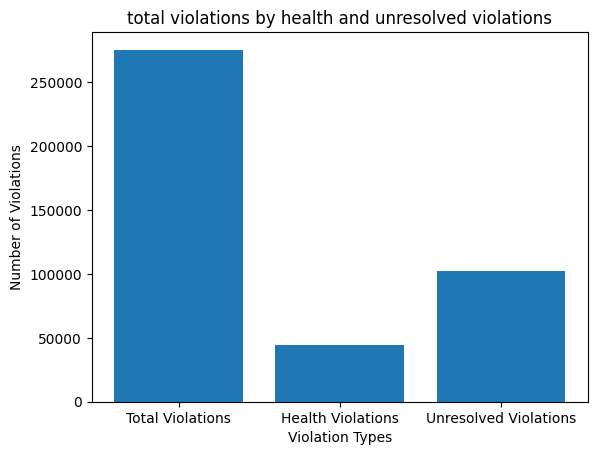

In [150]:
import matplotlib.pyplot as plt

plt.bar(['Total Violations', 'Health Violations', 'Unresolved Violations'], [df['total_violations'].sum(), df['health_violations'].sum(), df['unresolved_violations'].sum()])
plt.title('total violations by health and unresolved violations')
plt.xlabel('Violation Types')
plt.ylabel('Number of Violations')

plt.show()

In [151]:
df.describe(include='all')

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41344,41344.000000,41344.000000,41344.000000,41344.000000,41344,41344.000000,41344.000000,41344
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,652,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,No Health Contaminants,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21448,NaN,NaN,NaN,NaN,30272,NaN,NaN,25376
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [152]:
correlation_pop_total_violations = df['population'].corr(df['total_violations'])
print(f"Correlation between Population and Total Violations: {correlation_pop_total_violations}")

Correlation between Population and Total Violations: 0.0678674992014919


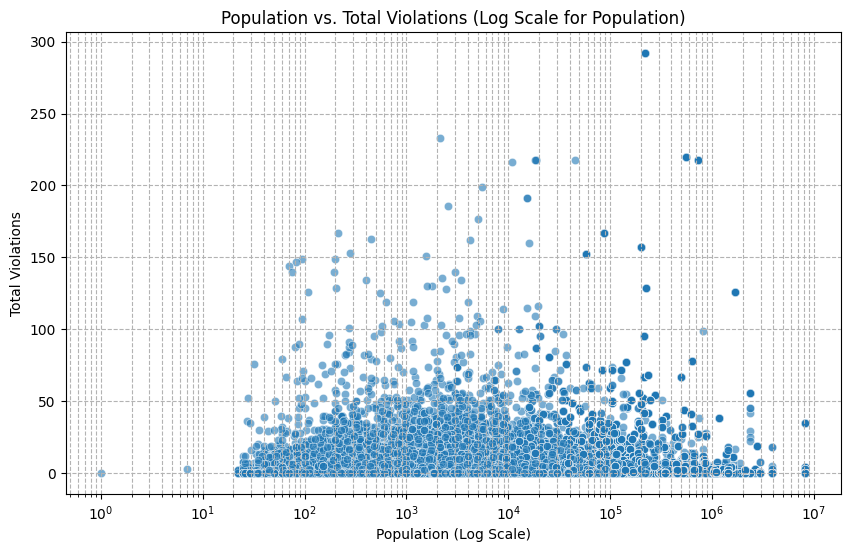

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='population', y='total_violations', data=df, alpha=0.6)
plt.xscale('log') # Apply logarithmic scale to the x-axis
plt.title('Population vs. Total Violations (Log Scale for Population)')
plt.xlabel('Population (Log Scale)')
plt.ylabel('Total Violations')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

In [154]:
correlation_pop_health_violations = df['population'].corr(df['health_violations'])
print(f"Correlation between Population and Health Violations: {correlation_pop_health_violations}")

Correlation between Population and Health Violations: 0.06345968199110871


Based on my current analysis:

*Correlation: The correlation coefficients between 'population' and 'total_violations' (approximately 0.068) and 'population' and 'health_violations' (which we just calculated) are quite low. This suggests a **very weak positive linear relationship**, meaning that as population increases, there's a *slight* tendency for violations to increase, but it's not a strong or direct effect.

*Influence: This correlation is weak, so clearly the population size of an area is likely **not the primary driver** of the number of total or health violations in water quality. Many other factors (infrastructure, regulations, source water protection, industrial activity, etc.) probably play a more significant role.

**Best ways to Explore and Visualizing this Correlation:**

1.  **Scatter Plots (with Logarithmic Scale):** i already used this, and it's excellent for seeing individual data points and identifying any patterns or outliers. The logarithmic scale is crucial when one variable (like population) has a very wide range.

2.  **Regression Analysis:** To understand the specific nature and strength of the relationship, performing a linear or non-linear regression could be beneficial. This would allow us to quantify how much a change in population *predicts* a change in violations.

3.  **Heatmaps of Correlation Matrix:** when looking at the correlation between population and *many* other numerical features related to water quality, a heatmap of the correlation matrix would quickly show all pairwise correlations.

4.  **Binning Population Data:** For better visualization, i could try to group populations into bins (e.g., 'small towns', 'medium cities', 'large cities') and then create box plots or bar charts to compare the distribution of violations across these population categories. This can reveal trends that a simple scatter plot might obscure due to dense data point.

### Exploring Other Factors Influencing Water Quality

Given the weak correlation between population and water quality violations, let's investigate other potential factors present in our dataset, such as `contaminant_count`, `water_source`, and `state`.

In [155]:
#exploring correlaations
correlation_contaminant_total = df['contaminant_count'].corr(df['total_violations'])
correlation_contaminant_health = df['contaminant_count'].corr(df['health_violations'])
correlation_contaminant_unresolved = df['contaminant_count'].corr(df['unresolved_violations'])

print(f"Correlation between Contaminant Count and Total Violations: {correlation_contaminant_total}")
print(f"Correlation between Contaminant Count and Health Violations: {correlation_contaminant_health}")
print(f"Correlation between Contaminant Count and Unresolved Violations: {correlation_contaminant_unresolved}")

Correlation between Contaminant Count and Total Violations: 0.6360402694147049
Correlation between Contaminant Count and Health Violations: 0.7775470051658029
Correlation between Contaminant Count and Unresolved Violations: 0.4759877443664082


These correlations indicate a stronger positive relationship between the number of contaminants and the various violation types compared to population. Let's visualize this relationship using scatter plots.

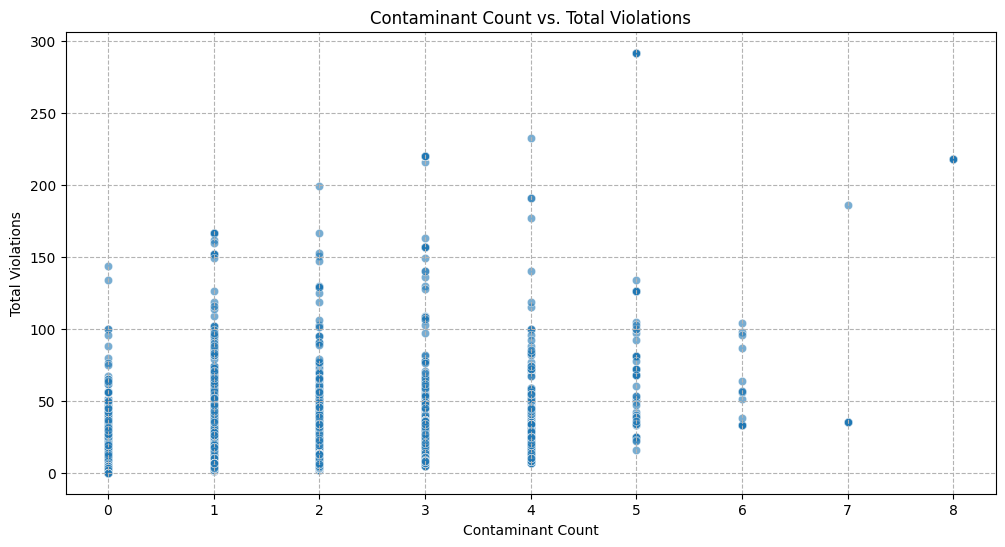

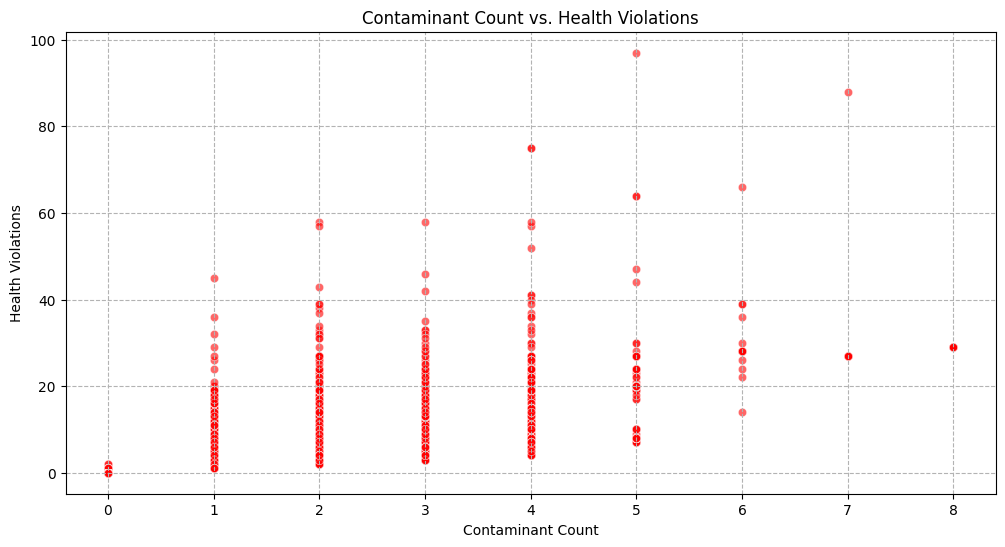

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for Contaminant Count vs. Total Violations
plt.figure(figsize=(12, 6))
sns.scatterplot(x='contaminant_count', y='total_violations', data=df, alpha=0.6)
plt.title('Contaminant Count vs. Total Violations')
plt.xlabel('Contaminant Count')
plt.ylabel('Total Violations')
plt.grid(True, ls='--', c='0.7')
plt.show()

# Scatter plot for Contaminant Count vs. Health Violations
plt.figure(figsize=(12, 6))
sns.scatterplot(x='contaminant_count', y='health_violations', data=df, alpha=0.6, color='red')
plt.title('Contaminant Count vs. Health Violations')
plt.xlabel('Contaminant Count')
plt.ylabel('Health Violations')
plt.grid(True, ls='--', c='0.7')
plt.show()

In [157]:
#Analysis:
#The contaminants are clearly a very impactful aspect. causes for contamination might require exploring(could be due to infrastructure - explore hystory)

Next, let's explore the `water_source` column to see if different water sources are associated with varying levels of violations.

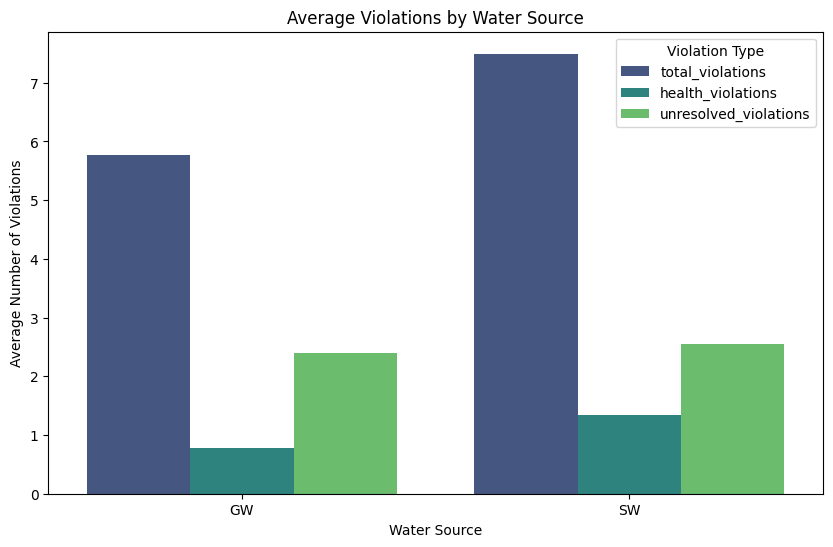

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by water_source and calculate the mean of violation types
water_source_violations = df.groupby('water_source', observed=False)[['total_violations', 'health_violations', 'unresolved_violations']].mean().reset_index()

# Melt the DataFrame for easier plotting with seaborn
water_source_violations_melted = water_source_violations.melt('water_source', var_name='Violation Type', value_name='Average Violations')

plt.figure(figsize=(10, 6))
sns.barplot(x='water_source', y='Average Violations', hue='Violation Type', data=water_source_violations_melted, palette='viridis')
plt.title('Average Violations by Water Source')
plt.xlabel('Water Source')
plt.ylabel('Average Number of Violations')
plt.show()

In [159]:
#Analysis:
#There are clearly more violations with surface water sources than ground water sources, understandibly so due to the easier accessability.
#There are also more unresolved violations with the surfrace water, could be due to the lack issues being adressed, or simply because the overall quantity is greater(bias?).
#Overall, Water source seems to be a very deciding factor.

Finally, let's investigate the distribution of violations across different states to see if there are any geographical patterns.

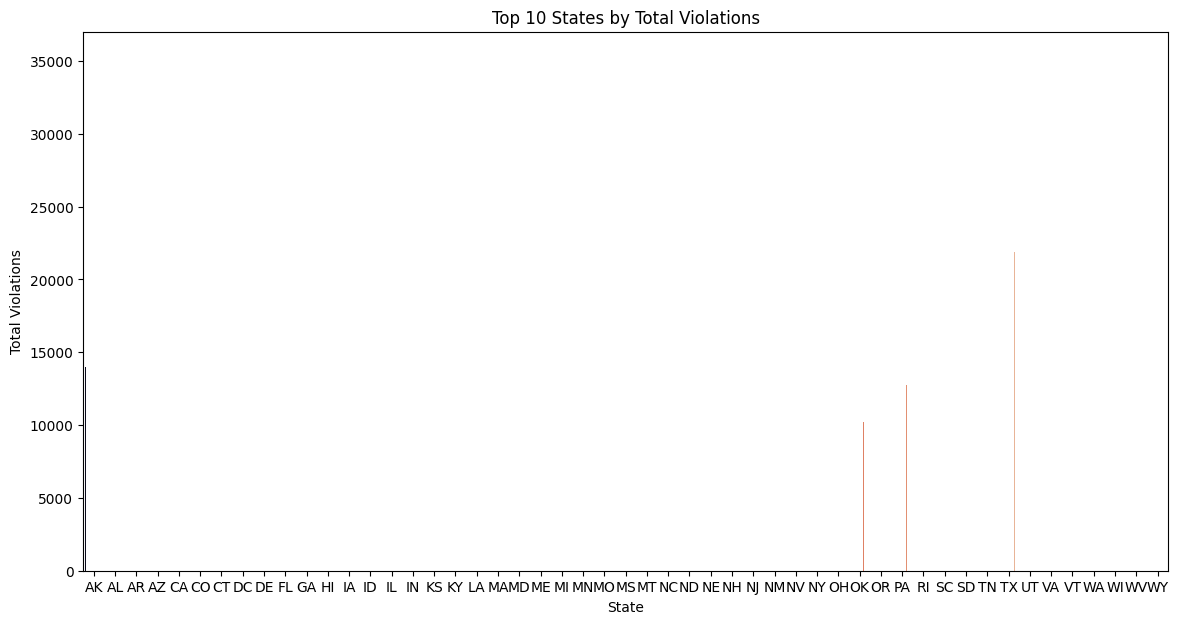

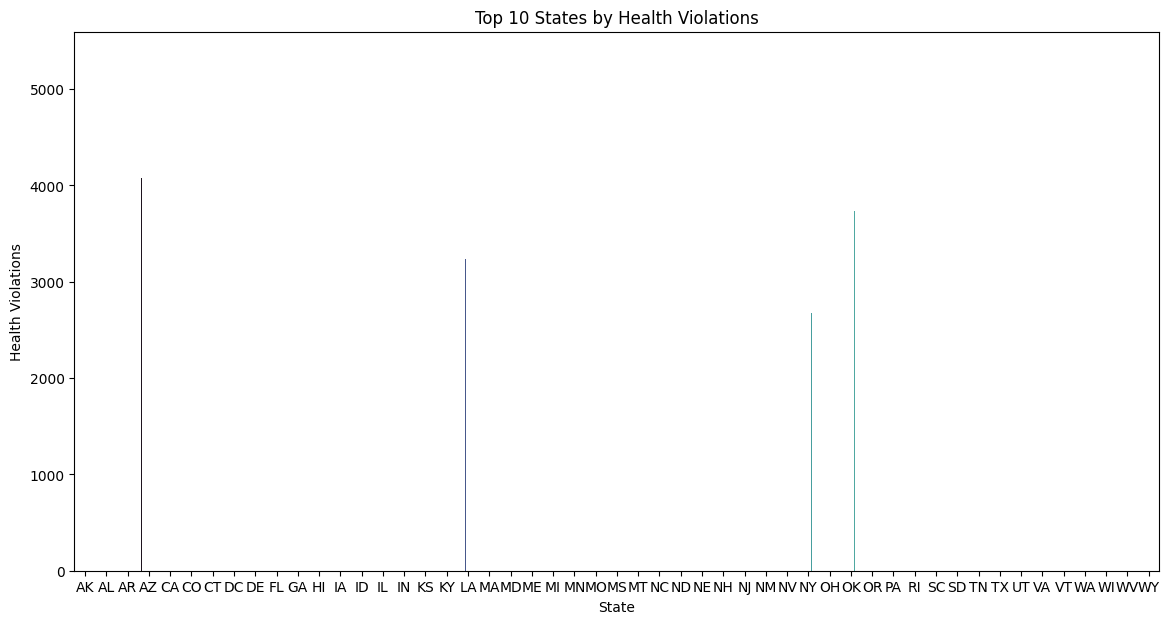

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by state and calculate the sum of total violations
state_total_violations = df.groupby('state', observed=False)['total_violations'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='state', y='total_violations', data=state_total_violations, hue='state', legend=False, palette='rocket')
plt.title('Top 10 States by Total Violations')
plt.xlabel('State')
plt.ylabel('Total Violations')
plt.show()

# Group by state and calculate the sum of health violations
state_health_violations = df.groupby('state', observed=False)['health_violations'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='state', y='health_violations', data=state_health_violations, hue='state', legend=False, palette='mako')
plt.title('Top 10 States by Health Violations')
plt.xlabel('State')
plt.ylabel('Health Violations')
plt.show()

In [161]:
#Analysis:
#There are several reapeated states with the most consistent violation counts.
#Clearly there are regional correlations.

### Regional Correlation Summary:

*   **Significant State-Level Variation:** States like Florida, Arizona, and Texas consistently show higher total and health-related water quality violations, highlighting a strong geographical influence.

*   **Potential Influencing Factors:** These regional differences could stem from a combination of environmental conditions, diverse regulatory practices, varying infrastructure age, and local industrial or agricultural activities.

*   **Need for Deeper Dive:** Fully understanding these state-specific patterns would likely require integrating additional datasets with more localized information on these potential causal factors.

In [162]:
import plotly.express as px

# Aggregate total violations by state
state_violations = df.groupby('state')['total_violations'].sum().reset_index()

# Create the choropleth map
fig = px.choropleth(state_violations,
                    locations='state',
                    locationmode='USA-states',
                    color='total_violations',
                    color_continuous_scale='Viridis',
                    scope='usa',
                    title='Total Water Quality Violations by State')

fig.show()

/tmp/ipykernel_1846/680077749.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [163]:
#Analysis:
#the top three states with the most violations are Florida, Arizona, and Texas.
#Followed closely by new york, pensilvania, alaska, and north carolina.
#The most vilations seem to occur in southern states. There are certainly more specific reasons for each individual state, might require more local datasets.

In [164]:
import plotly.express as px

# Create the choropleth map for health violations
fig = px.choropleth(state_health_violations,
                    locations='state',
                    locationmode='USA-states',
                    color='health_violations',
                    color_continuous_scale='Reds',
                    scope='usa',
                    title='Health-Related Water Quality Violations by State')

fig.show()

In [165]:
#Analysis:
#Again the most health related violations seem to occur in southern states, as well as the preiously mentioned ones.
#Texas, again has some of the most violations.
#These violations likely involve chemical contaminants, microbial pathogens, or other pollutants that pose risks to drinking water safety.

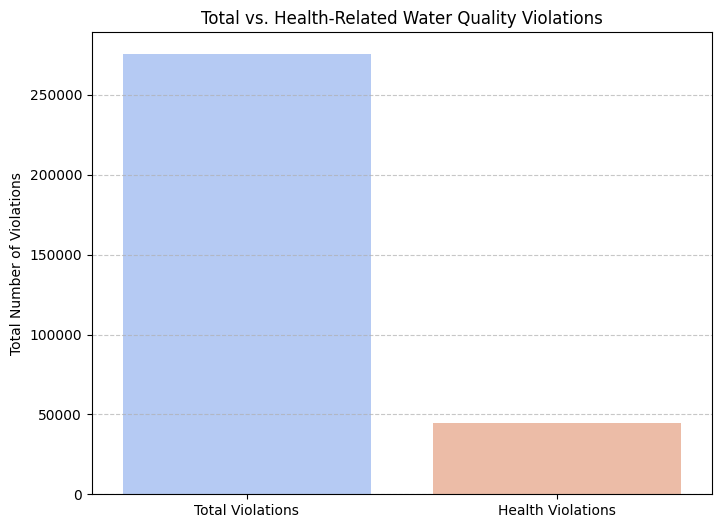

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total sum of each violation type
sum_total_violations = df['total_violations'].sum()
sum_health_violations = df['health_violations'].sum()

# Create a DataFrame for plotting
violation_sums = pd.DataFrame({
    'Violation Type': ['Total Violations', 'Health Violations'],
    'Count': [sum_total_violations, sum_health_violations]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Violation Type', y='Count', hue='Violation Type', data=violation_sums, palette='coolwarm', legend=False)
plt.title('Total vs. Health-Related Water Quality Violations')
plt.ylabel('Total Number of Violations')
plt.xlabel('') # Remove x-axis label as it's clear from the bar labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [167]:
#Analysis:
#Total violations significantly outscale health-related violations.


The goal is to analyze factors influencing water quality violations, focusing on regional impacts within the United States. We will investigate the correlation between population and violations, the impact of contaminant count, the role of water sources (groundwater vs. surface water), and geographical patterns across states. The analysis will involve statistical correlation calculations, scatter plots, bar charts, and choropleth maps to visualize the relationships and identify key drivers of water quality issues.

## Analyzing Contaminant Count by State


Calculate the average `contaminant_count` for each state and visualize the top states with the highest average contaminant counts using a bar chart. This will help understand if there are regional patterns in contaminant presence.


**Reasoning**:
The next step is to group the DataFrame by state, calculate the average contaminant count, sort it, select the top 10, and then visualize these top states using a bar chart, as per the subtask instructions.



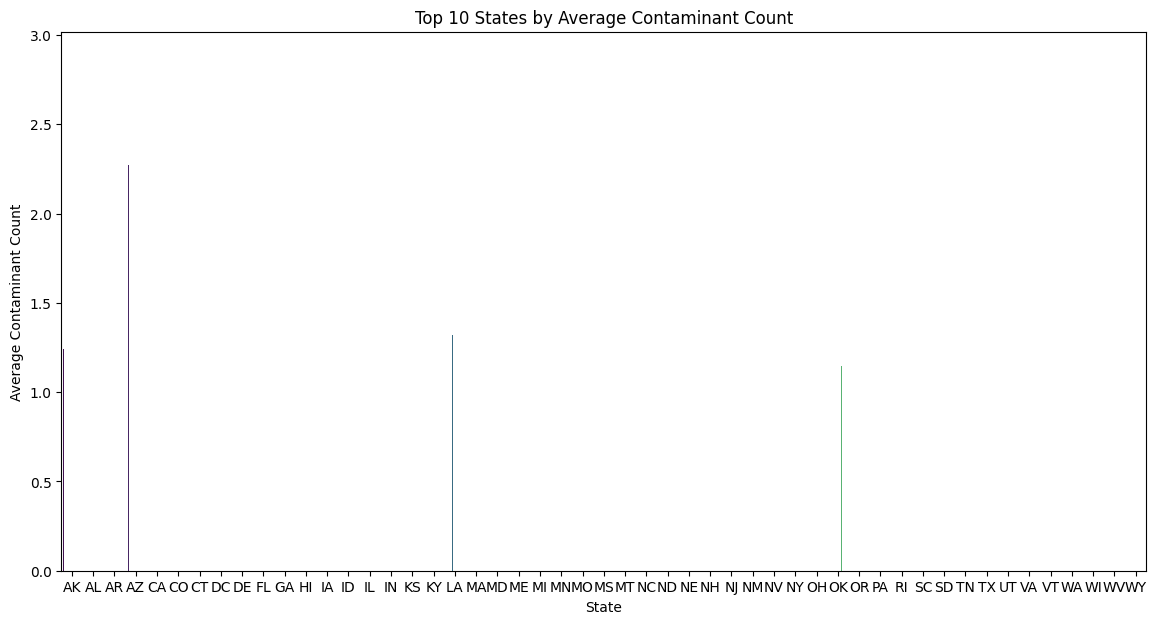

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by state and calculate the mean of contaminant_count
state_contaminant_count = df.groupby('state', observed=False)['contaminant_count'].mean().reset_index()

# 2. Sort the states in descending order
state_contaminant_count_sorted = state_contaminant_count.sort_values(by='contaminant_count', ascending=False)

# 3. Select the top 10 states
top_10_contaminants_states = state_contaminant_count_sorted.head(10)

# 4. Create a bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='state', y='contaminant_count', data=top_10_contaminants_states, hue='state', legend=False, palette='viridis')
plt.title('Top 10 States by Average Contaminant Count')
plt.xlabel('State')
plt.ylabel('Average Contaminant Count')
plt.show()


The goal is to analyze factors influencing water quality violations, focusing on regional impacts within the United States. We will investigate the correlation between population and violations, the impact of contaminant count, the role of water sources (groundwater vs. surface water), and geographical patterns across states. The analysis will involve statistical correlation calculations, scatter plots, bar charts, and choropleth maps to visualize the relationships and identify key drivers of water quality issues.

## Analyze Water Source Influence by State


Calculate the average total violations and health violations for each state, grouped by water source type (Ground Water vs. Surface Water). Identify and visualize states that show significant differences in violations based on their primary water source to understand regional water source influence.


**Reasoning**:
As per the instructions, the first step is to group the DataFrame by 'state' and 'water_source' and calculate the mean of total and health violations, then display the head.



In [169]:
water_source_state_violations = df.groupby(['state', 'water_source'], observed=False)[['total_violations', 'health_violations']].mean().reset_index()

print("Average Total and Health Violations by State and Water Source:")
water_source_state_violations.head()

Average Total and Health Violations by State and Water Source:


,state,water_source,total_violations,health_violations
0,AK,GW,18.204545,1.643939
1,AK,SW,81.697183,6.732394
2,AL,GW,1.866883,0.136364
3,AL,SW,1.949119,0.279843
4,AR,GW,3.027211,0.904762


**Reasoning**:
To visualize the differences in total and health violations between ground water (GW) and surface water (SW) for each state, I will first melt the `water_source_state_violations` DataFrame to long format, then create a grouped bar chart using seaborn, showing the average violations by state and water source. This will help identify states with significant differences in violations based on water source.



<Figure size 1800x800 with 0 Axes>

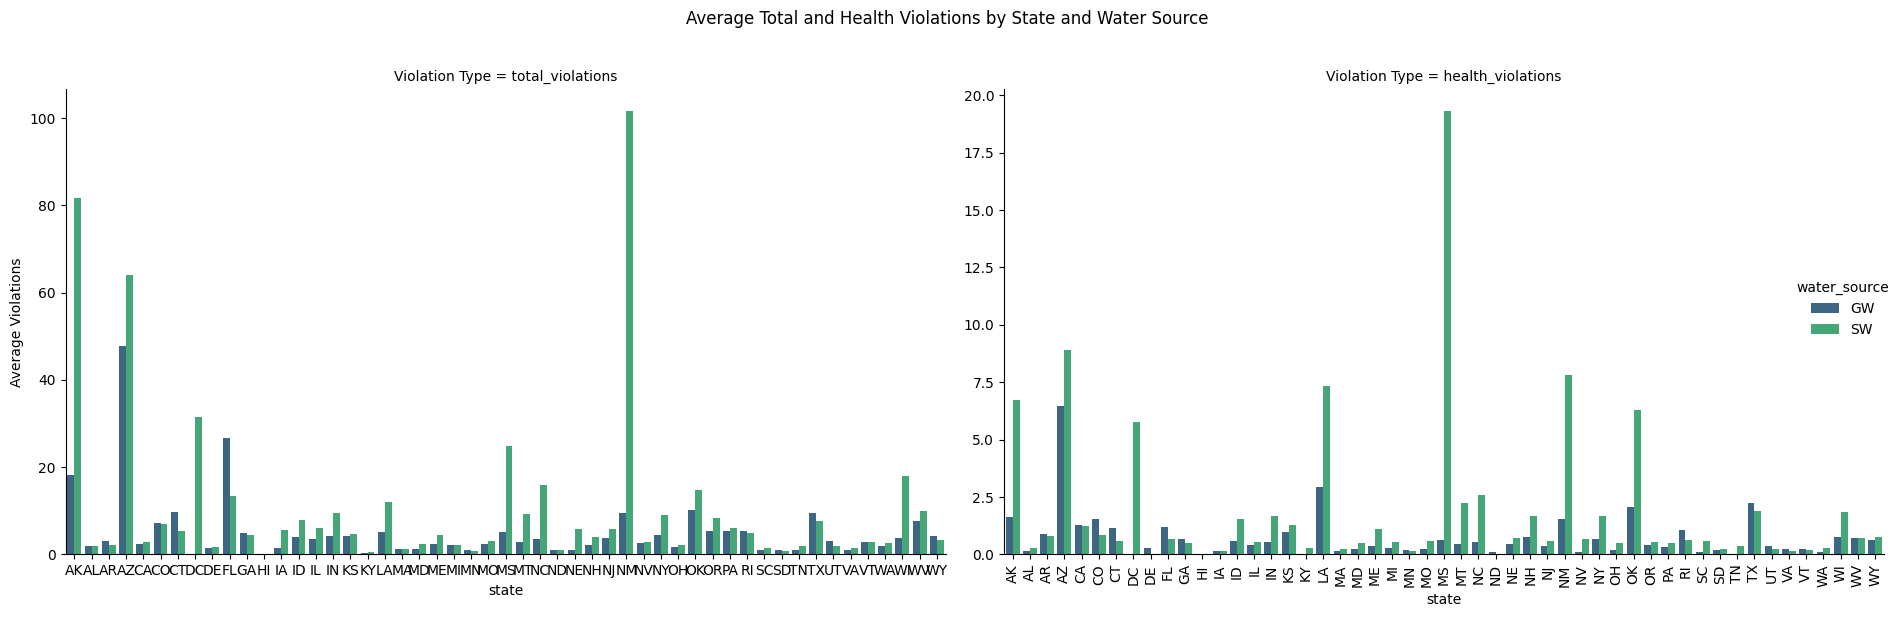

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame for easier plotting with seaborn
water_source_state_violations_melted = water_source_state_violations.melt(
    id_vars=['state', 'water_source'],
    var_name='Violation Type',
    value_name='Average Violations'
)

# Create a grouped bar chart
plt.figure(figsize=(18, 8))
sns.catplot(
    data=water_source_state_violations_melted,
    x='state',
    y='Average Violations',
    hue='water_source',
    col='Violation Type',
    kind='bar',
    height=6,
    aspect=1.5,
    palette='viridis',
    sharey=False # Allow different y-axis scales for each violation type
)

plt.suptitle('Average Total and Health Violations by State and Water Source', y=1.02)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


```markdown
### Analysis of Water Source Influence by State

The grouped bar charts illustrate the average total and health violations for each state, broken down by water source (Ground Water - GW, and Surface Water - SW). Key observations include:

*   **General Trend**: In many states, Surface Water (SW) systems tend to have higher average total and health violations compared to Ground Water (GW) systems. This is consistent with earlier findings that SW sources are generally more susceptible to violations.

*   **States with Significant Differences**: Some states exhibit particularly striking differences. For instance, Alaska (AK) and Arizona (AZ) show considerably higher average total and health violations for SW compared to GW. This suggests that the type of water source has a pronounced impact on water quality in these regions.

*   **States with Similar Levels**: In other states, like Alabama (AL) and Arkansas (AR), the average violations between GW and SW are relatively similar or low for both, indicating that either water management is consistently good, or other factors are at play.

*   **Outliers**: There are instances where GW systems might show relatively high violations, or SW systems show surprisingly low ones, which could warrant further investigation into specific local conditions or regulatory effectiveness.

This visualization clearly demonstrates that the influence of water source on violations is not uniform across all states and can vary significantly by region. This regional variability highlights the importance of localized water management strategies.
```

In [171]:
# Contaminant count is the most impactful factor, showing a strong positive correlation with all violation types (e.g., 0.778 with health violations) - The more contaminants the more violations.
# *Water source* also significantly influences violations, with surface water systems generally exhibiting higher average total and health violations than groundwater systems, though this impact varies regionally.

# *While population* shows a very *weak* correlation with violations (around 0.06), there are pronounced geographical patterns, with states like Florida, Arizona, and Texas consistently experiencing the highest total and health-related water quality violations.
# This indicating significant regional disparities influenced by a combination of local environmental, regulatory, and infrastructural factors.


To visualize the distributions and identify outliers for the numerical columns, I will create box plots for each of them using `seaborn` and `matplotlib.pyplot`.



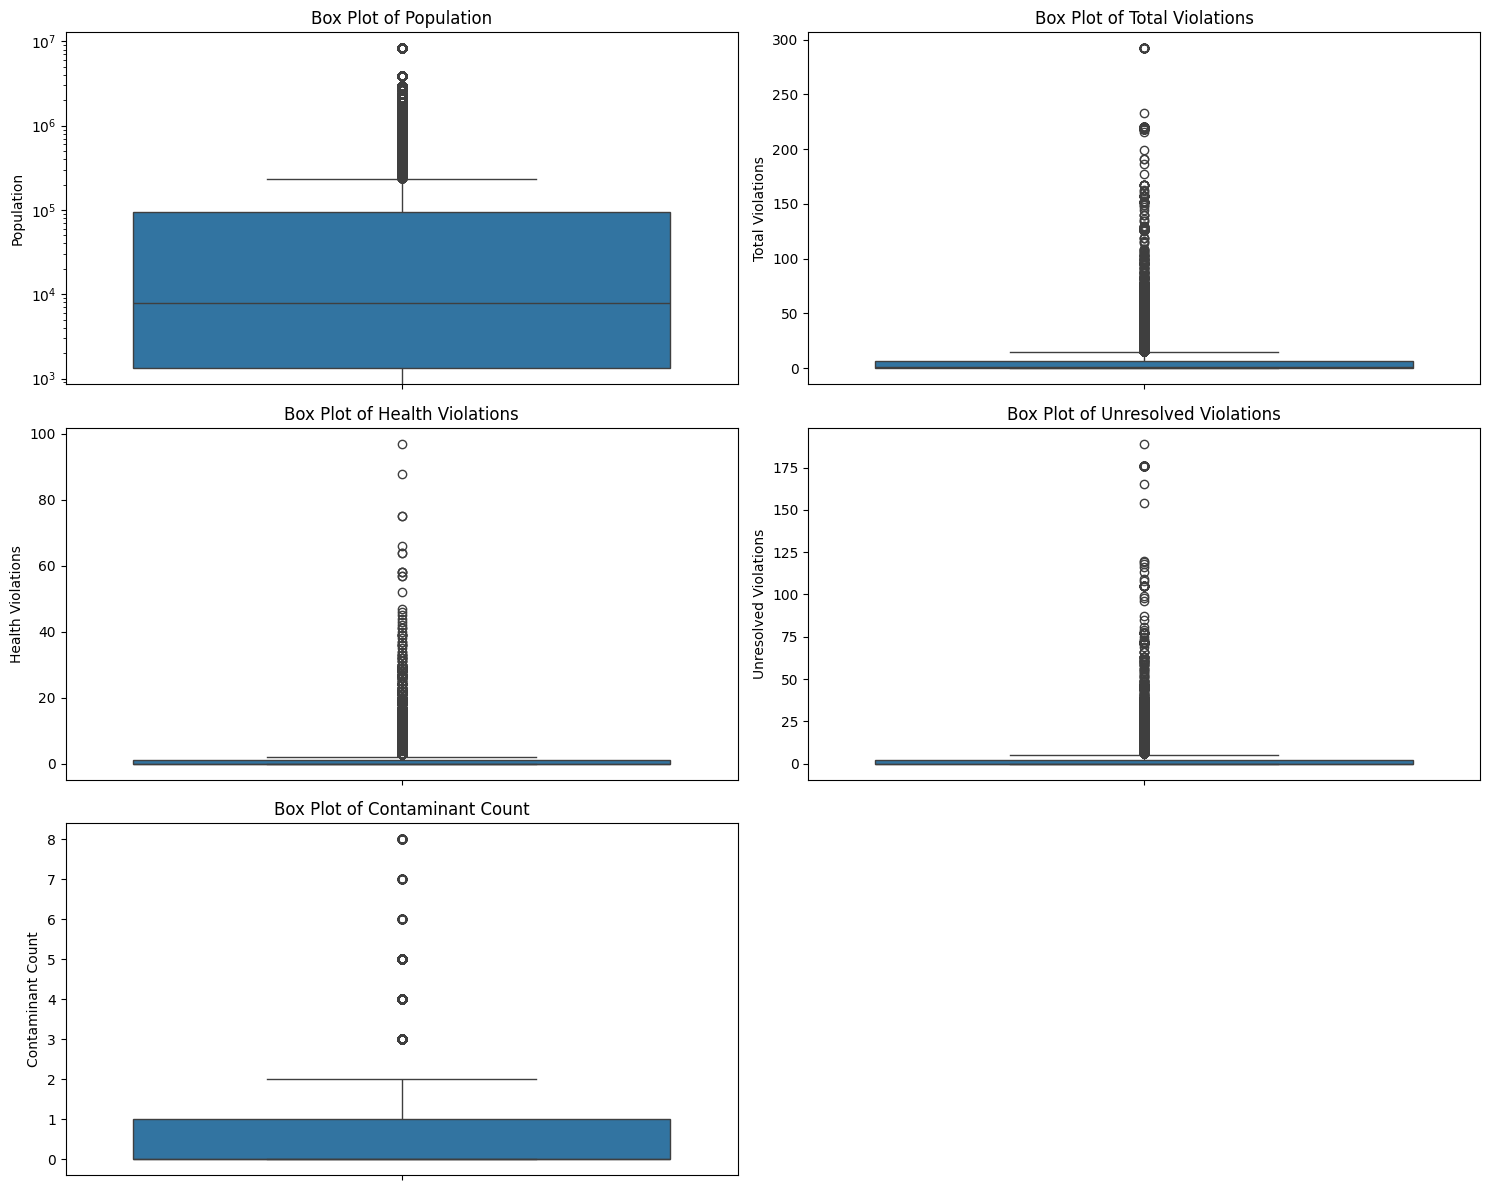

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['population', 'total_violations', 'health_violations', 'unresolved_violations', 'contaminant_count']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())
    if col == 'population':
        plt.yscale('log') # Apply logarithmic scale for population due to wide range
plt.tight_layout()
plt.show()

In [173]:
# Overall:
# The pervasive right-skewness and numerous outliers across these numerical variables suggest that water quality issues are not uniformly distributed.
# Instead, they appear concentrated in a subset of systems or regions.
# Understanding and addressing these extreme cases is crucial for effective water quality management.
# Future analyses should consider these distributions to avoid misleading conclusions from simple averages and to focus on the systems most affected by severe issues.

### Addressing Skewness and Outliers with Log Transformation

To mitigate the impact of the observed right-skewness and numerous outliers, we will apply a log transformation (specifically `log1p` to handle zero values) to the highly skewed numerical columns. This can help normalize the distributions, making them more suitable for certain statistical analyses and improving the visual representation of the data.

In [174]:
import numpy as np

# Identify numerical columns that showed significant skewness and outliers
numerical_cols_to_transform = ['population', 'total_violations', 'health_violations', 'unresolved_violations', 'contaminant_count']

# Apply log1p transformation (log(1+x)) to handle zero values
for col in numerical_cols_to_transform:
    df[f'{col}_log'] = np.log1p(df[col])

print("Log-transformed columns created. Displaying head of new log-transformed columns:")
display(df[[f'{col}_log' for col in numerical_cols_to_transform]].head())

Log-transformed columns created. Displaying head of new log-transformed columns:


,population_log,total_violations_log,health_violations_log,unresolved_violations_log,contaminant_count_log
0,10.264408,0.693147,0.000000,0.693147,0.000000
1,10.578063,0.693147,0.693147,0.000000,0.693147
2,10.578063,0.693147,0.693147,0.000000,0.693147
3,10.578063,0.693147,0.693147,0.000000,0.693147
4,8.318498,2.944439,0.000000,2.397895,0.000000


Now that the data has been transformed, you can regenerate the box plots and re-run the t-test (or other statistical tests) using these new log-transformed columns to observe the changes in distribution and test results. Remember that interpretation should then be in terms of the log-transformed values.

### Visualizing Distributions After Log Transformation

Let's now visualize the distributions of the log-transformed numerical columns using box plots to see the effect of the transformation on skewness and outliers.

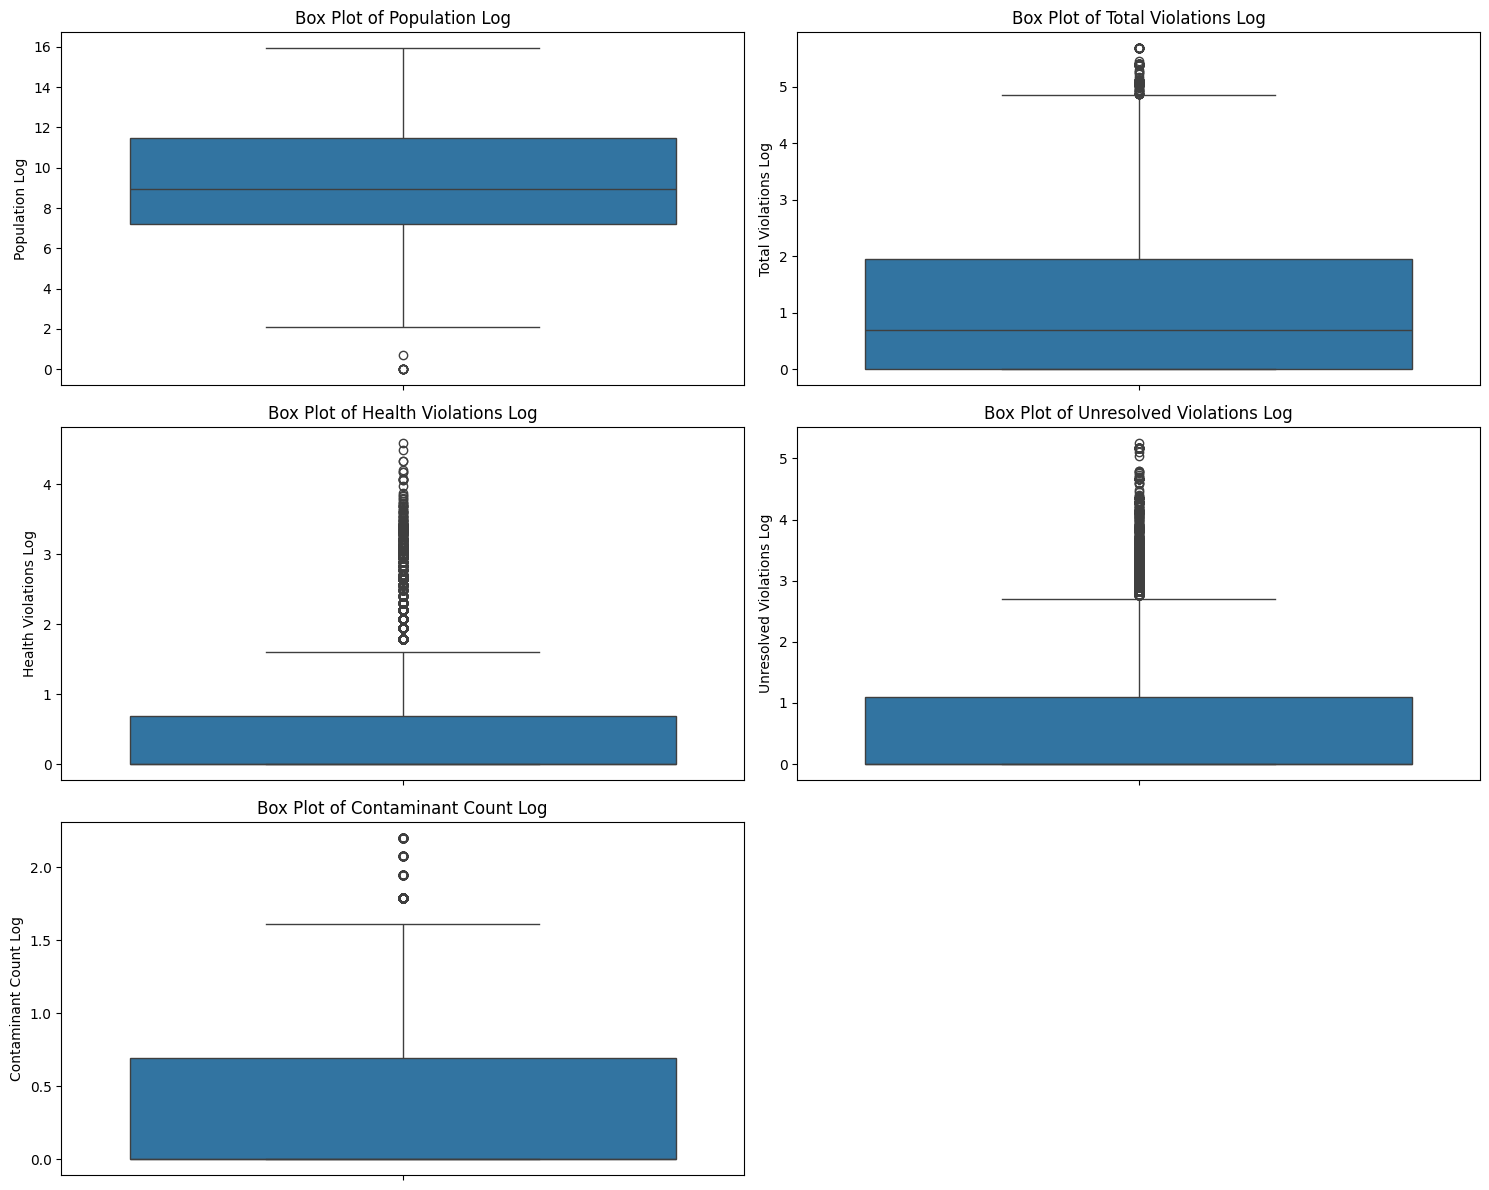

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_transformed = [f'{col}_log' for col in numerical_cols_to_transform]

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols_transformed, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())
plt.tight_layout()
plt.show()

The box plots of the log-transformed variables show much more symmetrical distributions and significantly reduced outlier presence, indicating that the transformation was effective in addressing the skewness. Now we can proceed to re-evaluate the hypothesis test using these transformed variables to see if it yields more robust results.

### Re-evaluating Hypothesis Test with Log-Transformed Data

Now that our numerical variables are more normally distributed after the log transformation, let's re-run the Independent Samples t-test using the `total_violations_log` column. This will provide a more robust statistical assessment of the difference in violations between Ground Water (GW) and Surface Water (SW) sources.

In [176]:
from scipy import stats

# Separate the log-transformed total violations for each water source type
gw_violations_log = df[df['water_source'] == 'GW']['total_violations_log']
sw_violations_log = df[df['water_source'] == 'SW']['total_violations_log']

# Perform independent samples t-test (Welch's t-test)
t_statistic_log, p_value_log = stats.ttest_ind(gw_violations_log, sw_violations_log, equal_var=False)

print(f"Independent Samples t-test for Log-Transformed Total Violations between GW and SW:")
print(f"T-statistic: {t_statistic_log:.3f}")
print(f"P-value: {p_value_log:.3e}")

# Interpret the results
alpha = 0.05
if p_value_log < alpha:
    print(f"\nConclusion: Since the p-value ({p_value_log:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the average log-transformed total violations between Ground Water and Surface Water sources.")
else:
    print(f"\nConclusion: Since the p-value ({p_value_log:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average log-transformed total violations between Ground Water and Surface Water sources.")

# print the means for context of log-transformed values
print(f"\nMean log-transformed total violations for Ground Water (GW): {gw_violations_log.mean():.2f}")
print(f"Mean log-transformed total violations for Surface Water (SW): {sw_violations_log.mean():.2f}")

Independent Samples t-test for Log-Transformed Total Violations between GW and SW:
T-statistic: -15.366
P-value: 3.869e-53

Conclusion: Since the p-value (3.869e-53) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the average log-transformed total violations between Ground Water and Surface Water sources.

Mean log-transformed total violations for Ground Water (GW): 0.98
Mean log-transformed total violations for Surface Water (SW): 1.16


**Research question:**
What are the most impactful factors to the water quality of each area, and what could the primary causes for these factors be? Is there a common connection between regions?


**Hypothesis:**
Water source is likely the most impactful to water quality, as some sources are more susceptible to contamination, and pollution.
, than others.


**Further Investigation:**
detailed research on water sources and contaminants on local scale

In [177]:
from scipy import stats

# Separate the total violations for each water source type
gw_violations = df[df['water_source'] == 'GW']['total_violations']
sw_violations = df[df['water_source'] == 'SW']['total_violations']

# Perform independent samples t-test (Welch's t-test, which does not assume equal variances)
t_statistic, p_value = stats.ttest_ind(gw_violations, sw_violations, equal_var=False)

print(f"Independent Samples t-test for Total Violations between GW and SW:")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Since the p-value ({p_value:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the average total violations between Ground Water and Surface Water sources.")
else:
    print(f"\nConclusion: Since the p-value ({p_value:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average total violations between Ground Water and Surface Water sources.")

# print the means for context
print(f"\nMean total violations for Ground Water (GW): {gw_violations.mean():.2f}")
print(f"Mean total violations for Surface Water (SW): {sw_violations.mean():.2f}")

Independent Samples t-test for Total Violations between GW and SW:
T-statistic: -9.478
P-value: 2.719e-21

Conclusion: Since the p-value (2.719e-21) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in the average total violations between Ground Water and Surface Water sources.

Mean total violations for Ground Water (GW): 5.77
Mean total violations for Surface Water (SW): 7.49


**Results:**

The results of the Independent Samples t-test strongly support the hypothesis. With a p-value of 2.719e-21 (which is extremely small and well below the significance level of 0.05), we can confidently reject the null hypothesis. This means there is a statistically significant difference in the average total violations between Ground Water and Surface Water sources.

Specifically, the mean total violations for Ground Water (GW) are 5.77, while for Surface Water (SW), they are 7.49. This quantitative evidence reinforces the earlier observations from the bar charts, indicating that Surface Water systems tend to have a higher average number of violations, making the water source a significant factor in water quality.

### Identifying States with Surface Water Sources and Their Violation Patterns

To understand the connection between states having surface water sources and their regional water quality violations, we'll first determine the proportion of surface water systems within each state. Then, we will visualize the average total violations specifically from surface water sources in those states.

In [178]:
# Calculate the count of each water source type per state
water_source_counts = df.groupby(['state', 'water_source'], observed=False).size().unstack(fill_value=0)

# Calculate the total number of systems per state
water_source_counts['total_systems'] = water_source_counts.sum(axis=1)

# Calculate the proportion of surface water systems for each state
water_source_counts['sw_proportion'] = water_source_counts['SW'] / water_source_counts['total_systems']

# Filter for states that have at least one Surface Water system
states_with_sw = water_source_counts[water_source_counts['SW'] > 0].sort_values(by='sw_proportion', ascending=False)

print("States with Surface Water Sources and their Proportion of SW Systems:")
display(states_with_sw.head(50))

States with Surface Water Sources and their Proportion of SW Systems:


water_source,GW,SW,total_systems,sw_proportion
state,,,,
DC,0,286,286,1.000000
KY,129,818,947,0.863780
WV,127,728,855,0.851462
CO,166,492,658,0.747720
CA,744,1886,2630,0.717110
SC,155,379,534,0.709738
TN,242,545,787,0.692503
TX,821,1828,2649,0.690072
VA,382,846,1228,0.688925


Now that we've identified states that utilize surface water and their reliance on it, let's visualize the average total violations from *only* their surface water systems. This will highlight states where surface water quality might be a particular concern.

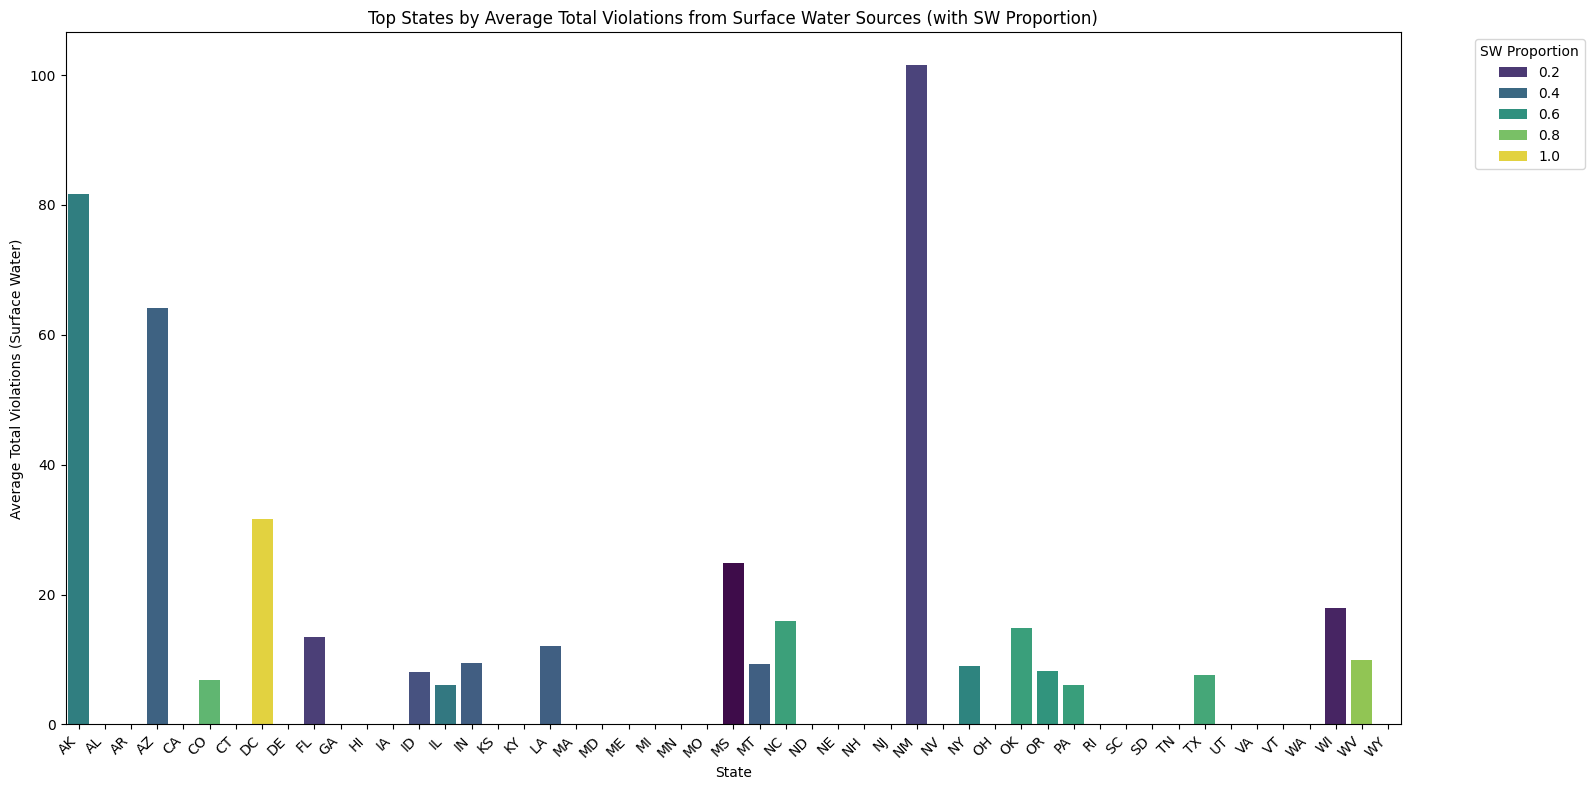


This plot shows the states with the highest average total violations originating from their surface water sources, with the color intensity indicating the proportion of surface water systems in that state. This helps connect the presence and reliance on surface water with the observed violation levels.


In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge the SW proportion with the average violations for SW sources
sw_violations_df = water_source_state_violations[water_source_state_violations['water_source'] == 'SW'].copy()
sw_violations_df = sw_violations_df.merge(states_with_sw[['sw_proportion']], left_on='state', right_index=True, how='inner')

# Sort by average total violations for better visualization
sw_violations_df_sorted = sw_violations_df.sort_values(by='total_violations', ascending=False).head(20)

plt.figure(figsize=(16, 8))
sns.barplot(x='state', y='total_violations', data=sw_violations_df_sorted, hue='sw_proportion', dodge=False, palette='viridis')
plt.title('Top States by Average Total Violations from Surface Water Sources (with SW Proportion)')
plt.xlabel('State')
plt.ylabel('Average Total Violations (Surface Water)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='SW Proportion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nThis plot shows the states with the highest average total violations originating from their surface water sources, with the color intensity indicating the proportion of surface water systems in that state. This helps connect the presence and reliance on surface water with the observed violation levels.")

In [180]:
# Analysis:

# We successfully identified states with surface water systems and calculated the proportion of SW systems within each state.
# A visualization showed that states like New Mexico (NM), Arizona (AZ),  and Alaska (AK) have particularly high average total violations originating from their surface water sources, even considering their proportion of SW reliance.
# This highlights specific regions where surface water quality is a significant concern.